<a href="https://colab.research.google.com/github/Amarnath718/FPGA-accelarated-VSLAM/blob/main/superpoint_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip SuperPoint-master.zip

Archive:  SuperPoint-master.zip
1411bbd68c50163555d39c1b26e9e046ebd48f27
   creating: SuperPoint-master/
 extracting: SuperPoint-master/.flake8  
 extracting: SuperPoint-master/.gitignore  
  inflating: SuperPoint-master/LICENSE.txt  
  inflating: SuperPoint-master/README.md  
  inflating: SuperPoint-master/convert_to_pytorch.ipynb  
   creating: SuperPoint-master/doc/
  inflating: SuperPoint-master/doc/SuperPoint_paper.pdf  
  inflating: SuperPoint-master/doc/hp-v_200.png  
  inflating: SuperPoint-master/doc/hp-v_235.png  
  inflating: SuperPoint-master/doc/hp-v_280.png  
  inflating: SuperPoint-master/makefile  
   creating: SuperPoint-master/notebooks/
  inflating: SuperPoint-master/notebooks/descriptors_evaluation_on_hpatches.ipynb  
  inflating: SuperPoint-master/notebooks/detector_evaluation_magic_point.ipynb  
  inflating: SuperPoint-master/notebooks/detector_repeatability_coco.ipynb  
  inflating: SuperPoint-master/notebooks/detector_repeatability_hpatches.ipynb  
  inflating: 

In [ ]:
%cd SuperPoint-master
!ls

/content/SuperPoint-master
convert_to_pytorch.ipynb  notebooks	     setup.py		    utils
doc			  pretrained_models  setup.sh		    weights
LICENSE.txt		  README.md	     superpoint
makefile		  requirements.txt   superpoint_pytorch.py


In [ ]:
!pip install torch torchvision opencv-python matplotlib numpy tqdm

In [ ]:
%cd /content/SuperPoint-master
!pip install -e .

/content/SuperPoint-master
Obtaining file:///content/SuperPoint-master
  Preparing metadata (setup.py) ... done
  Running setup.py develop for superpoint


In [ ]:
!ls weights

superpoint_v6_from_tf.pth


In [ ]:
from google.colab import files
files.upload()


Saving chess_board.jpg to chess_board.jpg


{'chess_board.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x13\x13\x12\x15\x13\x13\x13\x15\x16\x15\x17\x16\x17\x1a\x17\x18\x18\x18\x17\x17\x17\x18\x17\x18\x18\x17\x17\x18\x17\x17\x1a\x18\x1d( \x18\x1a%\x1d\x1d\x18!1!%)+...\x17\x1f383-7(-.+\x01\n\n\n\x0e\r\x0e\x1b\x10\x10\x1a-%\x1f%-------+--+---------------------------------------\xff\xc0\x00\x11\x08\x00\xb7\x01\x13\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1b\x00\x00\x01\x05\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x00\x01\x02\x03\x05\x06\x07\xff\xc4\x00>\x10\x00\x01\x03\x02\x02\x07\x07\x03\x02\x05\x03\x03\x05\x00\x00\x00\x01\x00\x02\x11\x03!\x041\x05\x12AQaq\xf0\x13"\x81\x91\xa1\xb1\xc1\x06\xd1\xe12\xf1\x14\x15BRb\x073\xa2#S\xb2$Cr\x82\x92\xff\xc4\x00\x18\x01\x00\x03\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\xff\xc4\x00 \x11\x01\x01\x00\x02\x02\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x01\x02\x11\x12!\x03"1Aa\

In [ ]:
import cv2

img = cv2.imread("chess_board.jpg", cv2.IMREAD_GRAYSCALE)
cv2.imwrite("chess_board_gray.png", img)


True

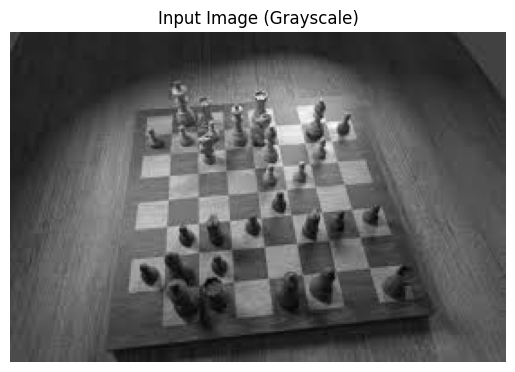

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')
plt.title("Input Image (Grayscale)")
plt.axis("off")
plt.show()

In [ ]:
%cd SuperPoint-master
import torch
import time
from superpoint_pytorch import SuperPoint

device = 'cpu'   # keep CPU for fair FPGA comparison

model = SuperPoint().to(device)

checkpoint = torch.load(
    'weights/superpoint_v6_from_tf.pth', # Corrected filename
    map_location=device
)

model.load_state_dict(checkpoint)
model.eval()

[Errno 2] No such file or directory: 'SuperPoint-master'
/content/SuperPoint-master


SuperPoint(
  (backbone): Sequential(
    (0): Sequential(
      (0): VGGBlock(
        (conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU(inplace=True)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): VGGBlock(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU(inplace=True)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): VGGBlock(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU(inplace=True)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): VGGBlock(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
import numpy as np

img_float = img.astype(np.float32) / 255.0

# Shape: [1, 1, H, W]
inp = torch.from_numpy(img_float)[None, None].to(device)


In [ ]:
start = time.time()

with torch.no_grad():
    output = model({"image": inp})

end = time.time()

print("SuperPoint CPU execution time:", end - start, "seconds")


SuperPoint CPU execution time: 0.6332933902740479 seconds


In [ ]:
keypoints = output["keypoints"][0].cpu().numpy()
print("Number of keypoints detected:", len(keypoints))


Number of keypoints detected: 286


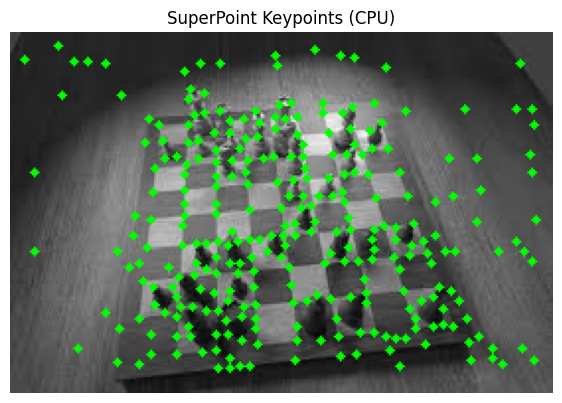

In [ ]:
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

for kp in keypoints:
    x, y = int(kp[0]), int(kp[1])
    cv2.circle(img_color, (x, y), 2, (0, 255, 0), -1)

plt.figure(figsize=(7,7))
plt.imshow(img_color)
plt.title("SuperPoint Keypoints (CPU)")
plt.axis("off")
plt.show()


In [ ]:
#To show the detected descriptors
descriptors = output["descriptors"][0].cpu().numpy()
print("Shape of descriptors:", descriptors.shape)
print("First 5 descriptors:\n", descriptors[:5])

Shape of descriptors: (286, 256)
First 5 descriptors:
 [[ 0.03632813  0.02251177 -0.04629478 ... -0.02977378  0.03370751
   0.10111009]
 [ 0.11130507  0.02320974  0.01792379 ... -0.07525908  0.0816068
  -0.12822688]
 [ 0.1720252  -0.0027082   0.05889083 ... -0.01494162  0.09617215
  -0.07606205]
 [ 0.08792901  0.02913541  0.01583072 ... -0.05127776  0.06476554
  -0.13074003]
 [ 0.11939309  0.02964891  0.01992049 ... -0.04985872  0.07625303
  -0.10443861]]
